# 05 — Error Estimation

Two independent methods quantify uncertainties on the 2PACF:

1. **Poisson errors** — analytic approximation $\sigma_w = \sqrt{(1+w)/DD}$.
2. **Simulation errors** — standard deviation of $w(\theta)$ across $N_{\rm cat}$
   synthetic catalogs generated by rigid sky rotations of collaborator N-body
   simulations through the survey mask.

Four simulation files are available, each with a different amplitude parameter α:
- `alpha0.5` — α = 0.5 (most commonly used in the original analysis)
- `alpha1`   — α = 1
- `alpha3`   — α = 3
- `default`  — original file, α unlabelled

The active simulation is set by `simulations.active` in `config/analysis.yml`.

> **Column-swap note**: `RA_sim_*.npy` contains Dec values and `DEC_sim_*.npy`
> contains RA values. This is corrected automatically in `src/errors.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.config import cfg, resolve_path
from src.correlation import CorrelationResult
from src.errors import compute_poisson_errors
from src.plotting import plot_2pacf_with_sim_errors

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ── USER SETTINGS ────────────────────────────────────────────────────────────
SAMPLE     = "edf_s_irac_footprint"   # sample to analyse
# SIM_NAME   = None means: use simulations.active from config/analysis.yml
# Set to e.g. "alpha1", "alpha3", "default" to pick a specific simulation
SIM_NAME   = None
# ─────────────────────────────────────────────────────────────────────────────

# Resolve active simulation name
active_sim = SIM_NAME or cfg["simulations"].get("active", "alpha0.5")
sim_label  = cfg["simulations"]["available"][active_sim]["label"]
print(f"Sample          : {SAMPLE}")
print(f"Active simulation: {active_sim}  ({sim_label})")
print(f"Available sims  : {list(cfg['simulations']['available'].keys())}")

Sample          : edf_s_irac_footprint
Active simulation: alpha0.5  (α = 0.5)
Available sims  : ['alpha0.5', 'alpha1', 'alpha3', 'default']


## 1. Load the observed 2PACF

In [2]:
corr_path = resolve_path(cfg["paths"]["corr_dir"]) / f"2pacf_{SAMPLE}.npz"

if not corr_path.exists():
    raise FileNotFoundError(
        f"Run notebook 03 first, or:\n"
        f"  python scripts/run_2pacf.py --sample {SAMPLE}"
    )

result  = CorrelationResult.load(str(corr_path))
poisson = compute_poisson_errors(result)

print(f"Loaded: {corr_path.name}")
print(f"N galaxies : {result.n_galaxies}")
print(f"N randoms  : {result.n_randoms}")
print(f"Valid bins : {result.valid.sum()} / {len(result.w)}")

Loaded: 2pacf_edf_s_irac_footprint.npz
N galaxies : 1028
N randoms  : 102800
Valid bins : 15 / 15


## 2. Load simulation errors for the active simulation

In [3]:
cov_dir  = resolve_path(cfg["paths"]["cov_dir"])
sim_path = cov_dir / f"sim_errors_{SAMPLE}_{active_sim}.npz"

if not sim_path.exists():
    print(
        f"Simulation errors not found at {sim_path}.\n"
        f"Run first:\n"
        f"  python scripts/run_simulations.py "
        f"--sample {SAMPLE} --sim-name {active_sim}"
    )
    sim_errors = None
else:
    data = np.load(str(sim_path))
    sim_errors = {
        "theta_deg"   : data["theta_deg"],
        "theta_arcmin": data["theta_arcmin"],
        "mean_w"      : data["mean_w"],
        "std_w"       : data["std_w"],
        "median_w"    : data["median_w"],
        "all_w"       : data["all_w"],
        "n_valid"     : data["n_valid"],
    }
    n_cats = int(data["n_catalogs"])
    print(f"Loaded: {sim_path.name}")
    print(f"  Simulation  : {active_sim}  ({sim_label})")
    print(f"  N catalogs  : {n_cats}")

Loaded: sim_errors_edf_s_irac_footprint_alpha0.5.npz
  Simulation  : alpha0.5  (α = 0.5)
  N catalogs  : 100


## 3. Bin-by-bin error comparison (Poisson vs Simulation)

In [4]:
if sim_errors is not None:
    print(f"{'θ [arcmin]':>12}  {'w(θ)':>10}  {'σ_Poisson':>12}  {'σ_Sim':>10}  {'σ_sim/σ_P':>10}")
    print("-" * 60)
    for i in range(len(result.theta_arcmin)):
        sig_p = poisson[i]
        sig_s = sim_errors["std_w"][i]
        ratio = sig_s / sig_p if (np.isfinite(sig_p) and sig_p > 0) else np.nan
        print(
            f"{result.theta_arcmin[i]:12.3f}  "
            f"{result.w[i]:10.5f}  "
            f"{sig_p:12.5f}  "
            f"{sig_s:10.5f}  "
            f"{ratio:10.2f}"
        )

  θ [arcmin]        w(θ)     σ_Poisson       σ_Sim   σ_sim/σ_P
------------------------------------------------------------
       0.668     0.14493       0.40443    12.54771       31.03
       1.004     0.08346       0.26876    26.13308       97.24
       1.505    -0.08252       0.18434     8.45128       45.85
       2.196     0.42254       0.12643    16.56432      131.02
       3.236     0.12706       0.08668    13.07936      150.89
       4.820     0.22224       0.05835   183.95906     3152.76
       7.200     0.11121       0.03929     6.71315      170.88
      10.581     0.12052       0.02636     2.76860      105.01
      15.675     0.05016       0.01786     2.04030      114.22
      23.347     0.03967       0.01214     1.52284      125.48
      34.452     0.02578       0.00836     0.63614       76.08
      51.088     0.02699       0.00583     0.49601       85.07
      75.579     0.02532       0.00417     0.18879       45.24
     111.395     0.00081       0.00314     0.12302       

## 4. Comparison plot: Poisson vs Simulation

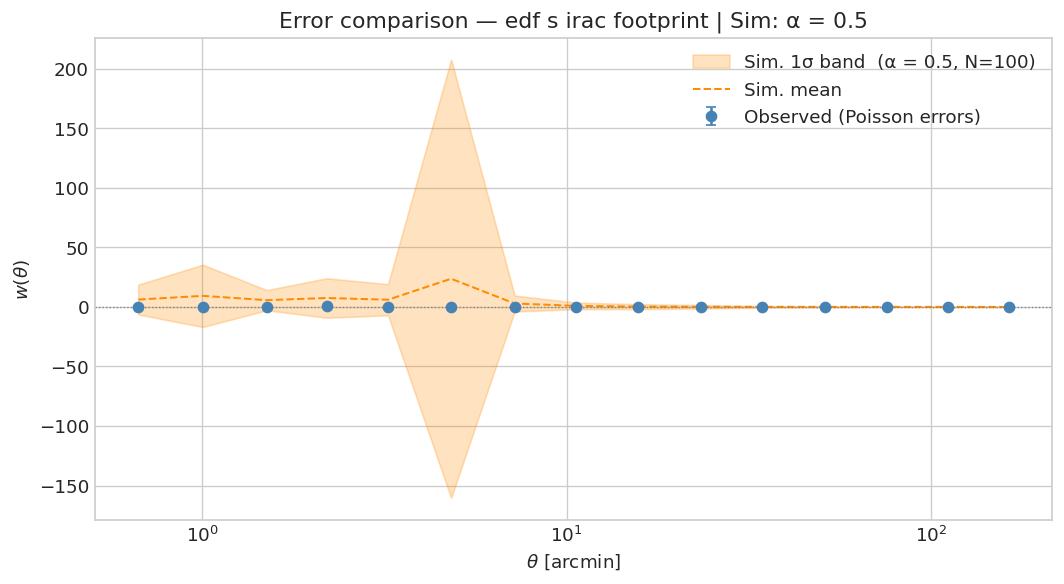

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
theta = result.theta_arcmin
w     = result.w

ax.errorbar(
    theta, w, yerr=poisson,
    fmt="o", color="steelblue", capsize=3, label="Observed (Poisson errors)",
    zorder=3,
)

if sim_errors is not None:
    ax.fill_between(
        theta,
        sim_errors["mean_w"] - sim_errors["std_w"],
        sim_errors["mean_w"] + sim_errors["std_w"],
        alpha=0.25, color="darkorange",
        label=f"Sim. 1σ band  ({sim_label}, N={n_cats})",
    )
    ax.plot(theta, sim_errors["mean_w"], "--", color="darkorange",
            linewidth=1.2, label="Sim. mean", zorder=2)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xscale("log")
ax.set_xlabel(r"$\theta$ [arcmin]")
ax.set_ylabel(r"$w(\theta)$")
ax.set_title(f"Error comparison — {SAMPLE.replace('_', ' ')} | Sim: {sim_label}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Multi-simulation comparison

Load all available simulation results and compare error bars side-by-side.
Run `python scripts/run_simulations.py --sample edf_s_irac_footprint --all-sims`
first to generate all results.

  Skipping alpha1 — not found: sim_errors_edf_s_irac_footprint_alpha1.npz
  Skipping alpha3 — not found: sim_errors_edf_s_irac_footprint_alpha3.npz
  Skipping default — not found: sim_errors_edf_s_irac_footprint_default.npz


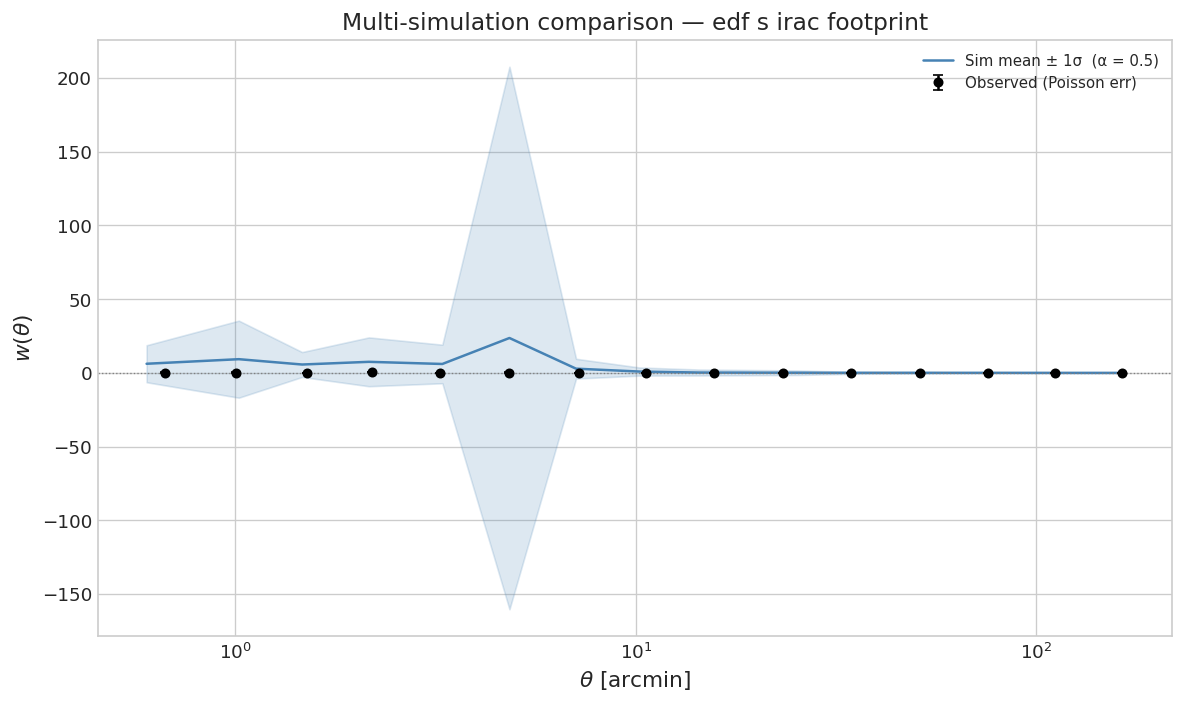

Plotted simulations: ['alpha0.5']


In [6]:
available = cfg["simulations"]["available"]
colors    = ["steelblue", "darkorange", "green", "purple"]

fig, ax = plt.subplots(figsize=(10, 6))

# Observed signal
ax.errorbar(
    result.theta_arcmin, result.w, yerr=poisson,
    fmt="ko", capsize=3, markersize=5,
    label="Observed (Poisson err)", zorder=5,
)

loaded_sims = []
for (sim_name, sim_info), color in zip(available.items(), colors):
    path = cov_dir / f"sim_errors_{SAMPLE}_{sim_name}.npz"
    if not path.exists():
        print(f"  Skipping {sim_name} — not found: {path.name}")
        continue
    d  = np.load(str(path))
    th = d["theta_arcmin"]
    m  = d["mean_w"]
    s  = d["std_w"]
    ax.fill_between(th, m - s, m + s, alpha=0.18, color=color)
    ax.plot(th, m, "-", color=color, linewidth=1.5,
            label=f"Sim mean ± 1σ  ({sim_info['label']})")
    loaded_sims.append(sim_name)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xscale("log")
ax.set_xlabel(r"$\theta$ [arcmin]", fontsize=13)
ax.set_ylabel(r"$w(\theta)$", fontsize=13)
ax.set_title(
    f"Multi-simulation comparison — {SAMPLE.replace('_', ' ')}",
    fontsize=14,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

if not loaded_sims:
    print("No simulation results found. Run first:")
    print(f"  python scripts/run_simulations.py --sample {SAMPLE} --all-sims")
else:
    print(f"Plotted simulations: {loaded_sims}")

## 6. Distribution of w(θ) across simulation realizations

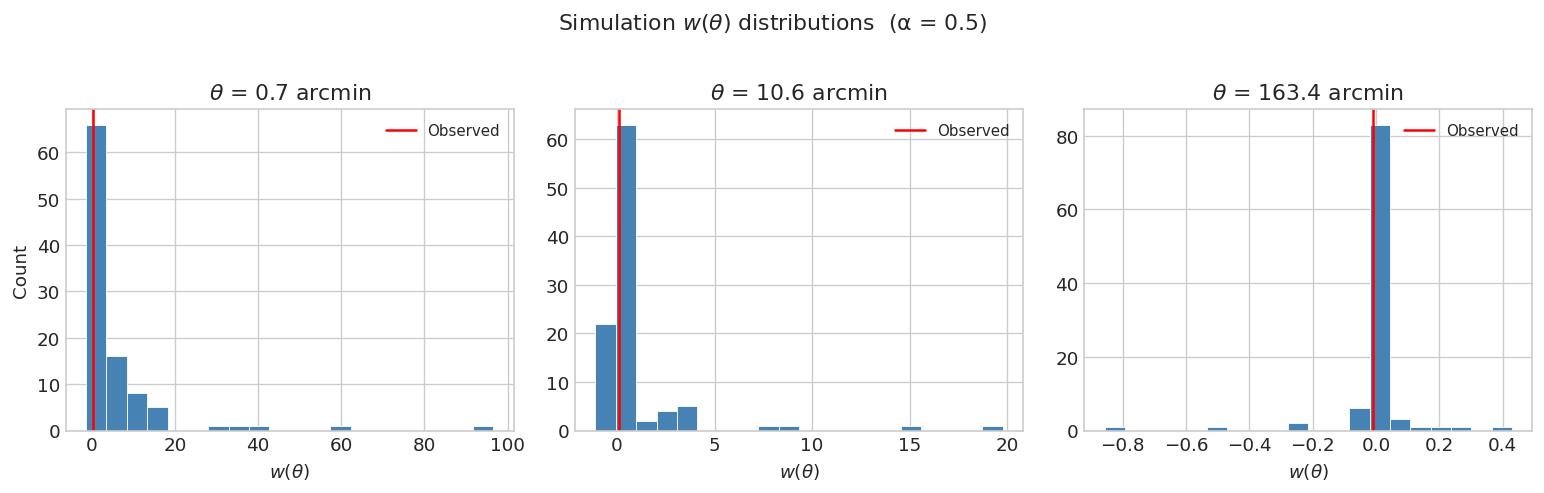

In [7]:
if sim_errors is not None:
    all_w  = sim_errors["all_w"]   # shape: (n_catalogs, n_bins)
    n_bins = all_w.shape[1]
    idx    = [0, n_bins // 2, n_bins - 1]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, i in zip(axes, idx):
        vals  = all_w[:, i]
        valid = np.isfinite(vals)
        ax.hist(vals[valid], bins=20, color="steelblue",
                edgecolor="white", linewidth=0.5)
        ax.axvline(result.w[i], color="red", linewidth=1.5, label="Observed")
        ax.set_xlabel(r"$w(\theta)$")
        ax.set_title(f"$\\theta$ = {result.theta_arcmin[i]:.1f} arcmin")
        ax.legend(fontsize=9)

    axes[0].set_ylabel("Count")
    plt.suptitle(
        f"Simulation $w(\\theta)$ distributions  ({sim_label})", y=1.02
    )
    plt.tight_layout()
    plt.show()

## Summary

| Method | Captures | Limitation |
|---|---|---|
| Poisson | Shot noise | Ignores cosmic variance and bin–bin correlations |
| Simulation | Cosmic variance via N-body sky rotations | Depends on simulation realism and α choice |
| OneCovariance | Full Gaussian covariance (shot + cosmic) | Assumes Gaussian field; computationally expensive |

The ratio $\sigma_{\rm sim} / \sigma_{\rm Poisson} > 1$ indicates that cosmic variance
contributes significantly on those angular scales.

Proceed to **06_covariance_analysis** for the full covariance matrix.